In [115]:
# Save the arrays to an NPZ file
import numpy as np
data = np.load('squeezed_embeddings.npz')

In [116]:
print(data.files)

['arr_0']


In [117]:
embeddings = data['arr_0']

In [118]:
import numpy as np
from PIL import Image

import os
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time

import plotly.graph_objects as go
from IPython.display import HTML

In [190]:
# Normalize the embeddings
scaler = StandardScaler()
normalized_embeddings = scaler.fit_transform(embeddings)

In [191]:
tsne = TSNE(n_components=3, learning_rate=150, perplexity=90, verbose=2).fit_transform(normalized_embeddings)

[t-SNE] Computing 271 nearest neighbors...
[t-SNE] Indexed 665 samples in 0.001s...
[t-SNE] Computed neighbors for 665 samples in 0.044s...
[t-SNE] Computed conditional probabilities for sample 665 / 665
[t-SNE] Mean sigma: 12.985895
[t-SNE] Computed conditional probabilities in 0.079s
[t-SNE] Iteration 50: error = 55.3864975, gradient norm = 0.0389791 (50 iterations in 0.550s)
[t-SNE] Iteration 100: error = 56.2959709, gradient norm = 0.0413948 (50 iterations in 0.512s)
[t-SNE] Iteration 150: error = 56.8179398, gradient norm = 0.0436104 (50 iterations in 0.505s)
[t-SNE] Iteration 200: error = 58.0991592, gradient norm = 0.0422662 (50 iterations in 0.494s)
[t-SNE] Iteration 250: error = 58.9314728, gradient norm = 0.0361640 (50 iterations in 0.474s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.931473
[t-SNE] Iteration 300: error = 1.0764667, gradient norm = 0.0028756 (50 iterations in 0.502s)
[t-SNE] Iteration 350: error = 1.0437407, gradient norm = 0.0054194

In [192]:
tx, ty = tsne[:,0], tsne[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))


In [193]:
import os
image_list = []
direc = '/projects/OLIVINE/data/test_folder_save_grain_img'

In [194]:
for filename in os.listdir(direc):
    full_path = os.path.join(direc, filename)
    image_list.append(full_path)

In [195]:
%matplotlib inline
import matplotlib.pyplot
from matplotlib.pyplot import imshow

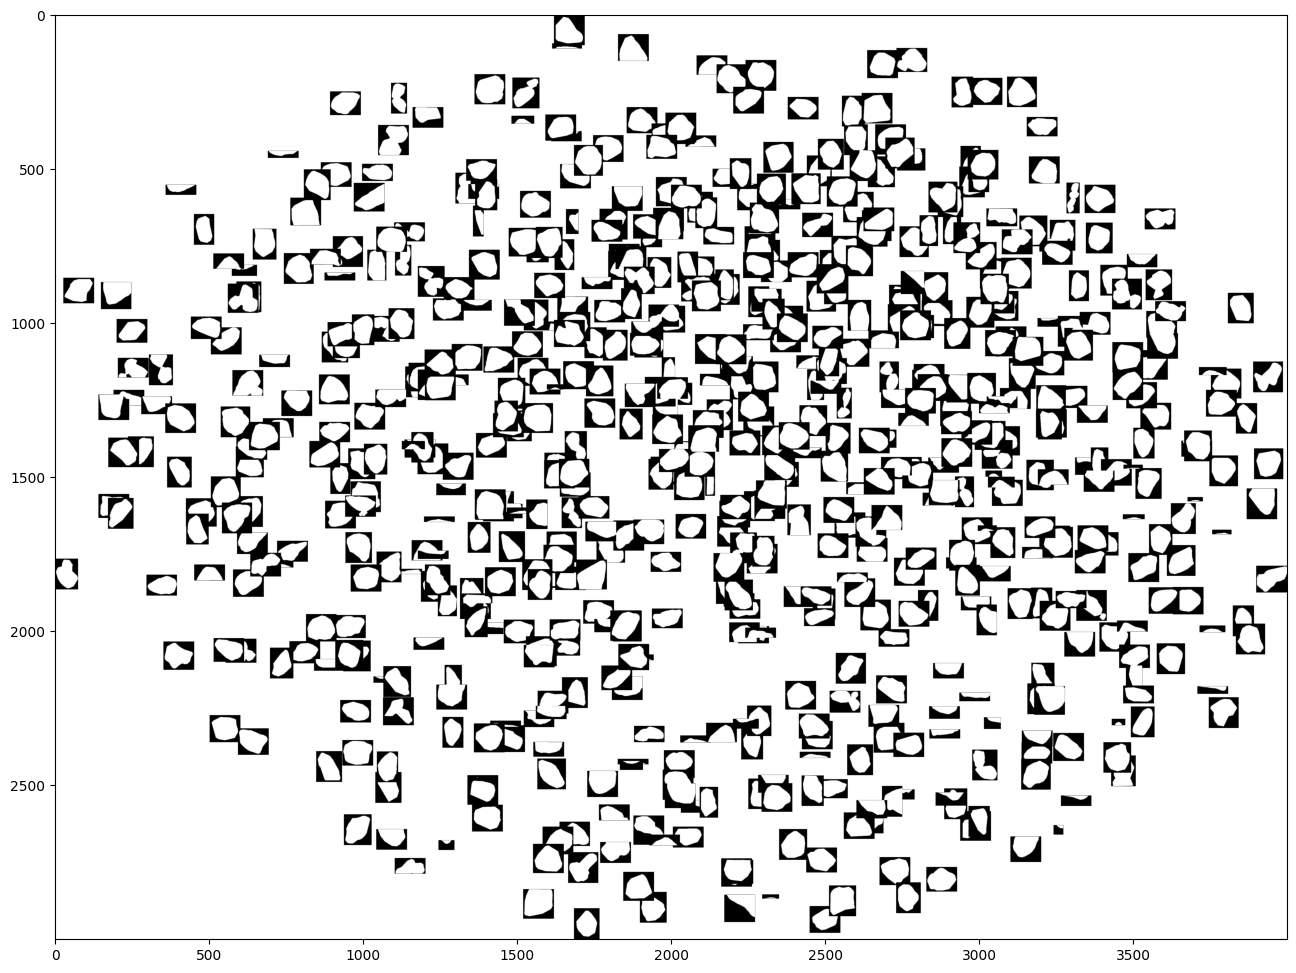

In [196]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(image_list, tx, ty):
    tile = Image.open(img)
    rs = max(1, tile.width/max_dim, tile.height/max_dim)
    tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
    full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)

In [177]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca_result = pca.fit_transform(normalized_embeddings)

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))


Explained variation per principal component: [0.19675192 0.15839905 0.11387352 0.05671125 0.05281387 0.04532244
 0.02969872 0.02786556 0.02225848 0.01986684 0.01565525 0.01519812
 0.01308485 0.01156989 0.01153571 0.00983317 0.00853097 0.00811745
 0.00759543 0.00658687 0.00595396 0.0054426  0.00528176 0.00513843
 0.00489749 0.00456317 0.00415372 0.00395522 0.00383901 0.00365932
 0.00345416 0.0033175  0.00321223 0.0030973  0.00293932 0.00269615
 0.0026533  0.00254511 0.00241907 0.0024057  0.00226294 0.00218131
 0.00212352 0.00204902 0.00199026 0.00193467 0.00187761 0.00184537
 0.00173003 0.00166206]


In [186]:
tsne = TSNE(n_components=2, learning_rate=150, perplexity=90, verbose=2).fit_transform(pca_result)

[t-SNE] Computing 271 nearest neighbors...
[t-SNE] Indexed 665 samples in 0.001s...
[t-SNE] Computed neighbors for 665 samples in 0.022s...
[t-SNE] Computed conditional probabilities for sample 665 / 665
[t-SNE] Mean sigma: 12.781458
[t-SNE] Computed conditional probabilities in 0.077s
[t-SNE] Iteration 50: error = 52.9435043, gradient norm = 0.1191407 (50 iterations in 0.140s)
[t-SNE] Iteration 100: error = 53.7304840, gradient norm = 0.1120280 (50 iterations in 0.137s)
[t-SNE] Iteration 150: error = 53.3627968, gradient norm = 0.1230204 (50 iterations in 0.136s)
[t-SNE] Iteration 200: error = 54.0175591, gradient norm = 0.1177211 (50 iterations in 0.142s)
[t-SNE] Iteration 250: error = 54.0775490, gradient norm = 0.1145665 (50 iterations in 0.141s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.077549
[t-SNE] Iteration 300: error = 0.7997327, gradient norm = 0.0030185 (50 iterations in 0.115s)
[t-SNE] Iteration 350: error = 0.7346914, gradient norm = 0.0031632

In [187]:
tx, ty = tsne[:,0], tsne[:,1]
tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))


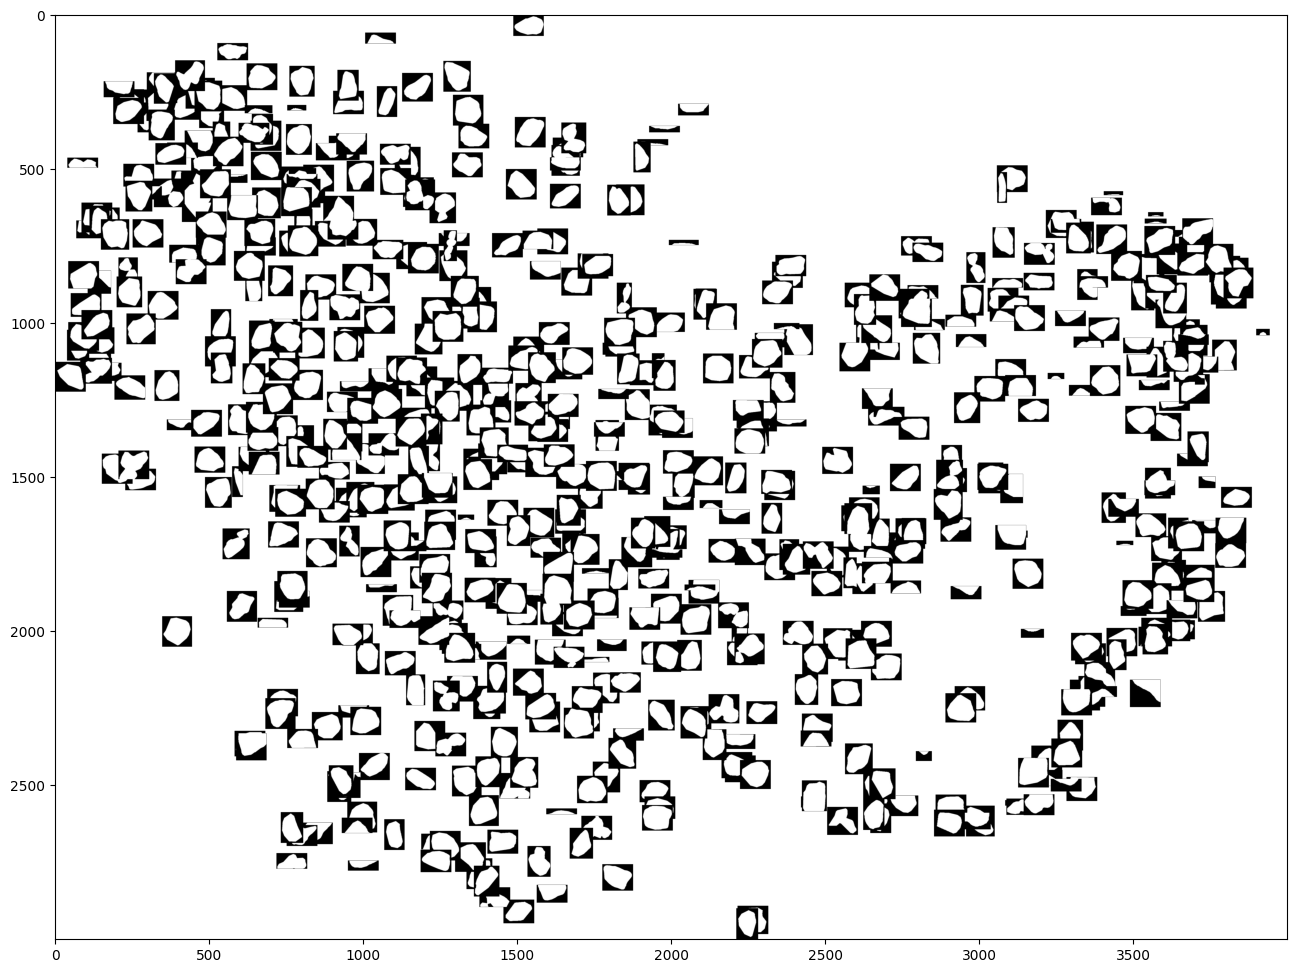

In [188]:
width = 4000
height = 3000
max_dim = 100

full_image = Image.new('RGBA', (width, height))
for img, x, y in zip(image_list, tx, ty):
    tile = Image.open(img)
    rs = max(1, tile.width/max_dim, tile.height/max_dim)
    tile = tile.resize((int(tile.width/rs), int(tile.height/rs)), Image.LANCZOS)
    full_image.paste(tile, (int((width-max_dim)*x), int((height-max_dim)*y)), mask=tile.convert('RGBA'))

matplotlib.pyplot.figure(figsize = (16,12))
imshow(full_image)